# Install Dependencies

In [1]:
!pip install ultralytics easyocr roboflow kaggle google-genai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 29.1 MB/s eta 0:00:00


# Import Libraries

In [8]:
import cv2
import re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import easyocr
from google import genai
from ultralytics import YOLO
from roboflow import Roboflow
from pathlib import Path
import os, shutil, glob
from google.colab import files

# Download Dataset

In [28]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("ahmad-rizki-sabani").project("splivu-12yrv")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kartikdullet/receipt-dataset-yolo -q
!unzip -q receipt-dataset-yolo.zip -d receipt_kaggle/

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kartikdullet/receipt-dataset-yolo
License(s): unknown


In [10]:
for split in ['train', 'val']:
    os.makedirs(f"combined_dataset/images/{split}", exist_ok=True)
    os.makedirs(f"combined_dataset/labels/{split}", exist_ok=True)

In [12]:
for split in ['train', 'val']:
    for img in glob.glob(f"receipt_kaggle/receipt_dataset/images/{split}/*"):
        shutil.copy(img, f"combined_dataset/images/{split}/")
    for lbl in glob.glob(f"receipt_kaggle/receipt_dataset/labels/{split}/*"):
        shutil.copy(lbl, f"combined_dataset/labels/{split}/")

In [13]:
for img in glob.glob(f"{dataset.location}/train/images/*"):
    shutil.copy(img, "combined_dataset/images/train/")
for lbl in glob.glob(f"{dataset.location}/train/labels/*"):
    shutil.copy(lbl, "combined_dataset/labels/train/")
for img in glob.glob(f"{dataset.location}/valid/images/*"):
    shutil.copy(img, "combined_dataset/images/val/")
for lbl in glob.glob(f"{dataset.location}/valid/labels/*"):
    shutil.copy(lbl, "combined_dataset/labels/val/")

In [15]:
yaml_content = """
train: /content/combined_dataset/images/train
val: /content/combined_dataset/images/val
nc: 1
names: ['receipt']
"""
with open("combined_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print(f"Train: {len(glob.glob('combined_dataset/images/train/*'))} gambar")
print(f"Val  : {len(glob.glob('combined_dataset/images/val/*'))} gambar")

Train: 566 gambar
Val  : 95 gambar


# Train

In [16]:
model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/combined_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="combined_receipt_detector",
    patience=10,
    device=0
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/combined_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=combined_receipt_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

# Evaluasi

In [17]:
best_model = YOLO("runs/detect/combined_receipt_detector/weights/best.pt")
metrics = best_model.val()

print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1473.8±487.6 MB/s, size: 41.4 KB)
val: Scanning /content/combined_dataset/labels/val.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 33.2Mit/s 0.0s
val: /content/combined_dataset/images/val/receipt30_jpg.rf.ed7d88168a377f94197ed5183080119e.jpg: 1 duplicate labels removed
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 95. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.4it/s 2.5s
                   all         95         95      0.999          1      0.995      0.956
Speed: 

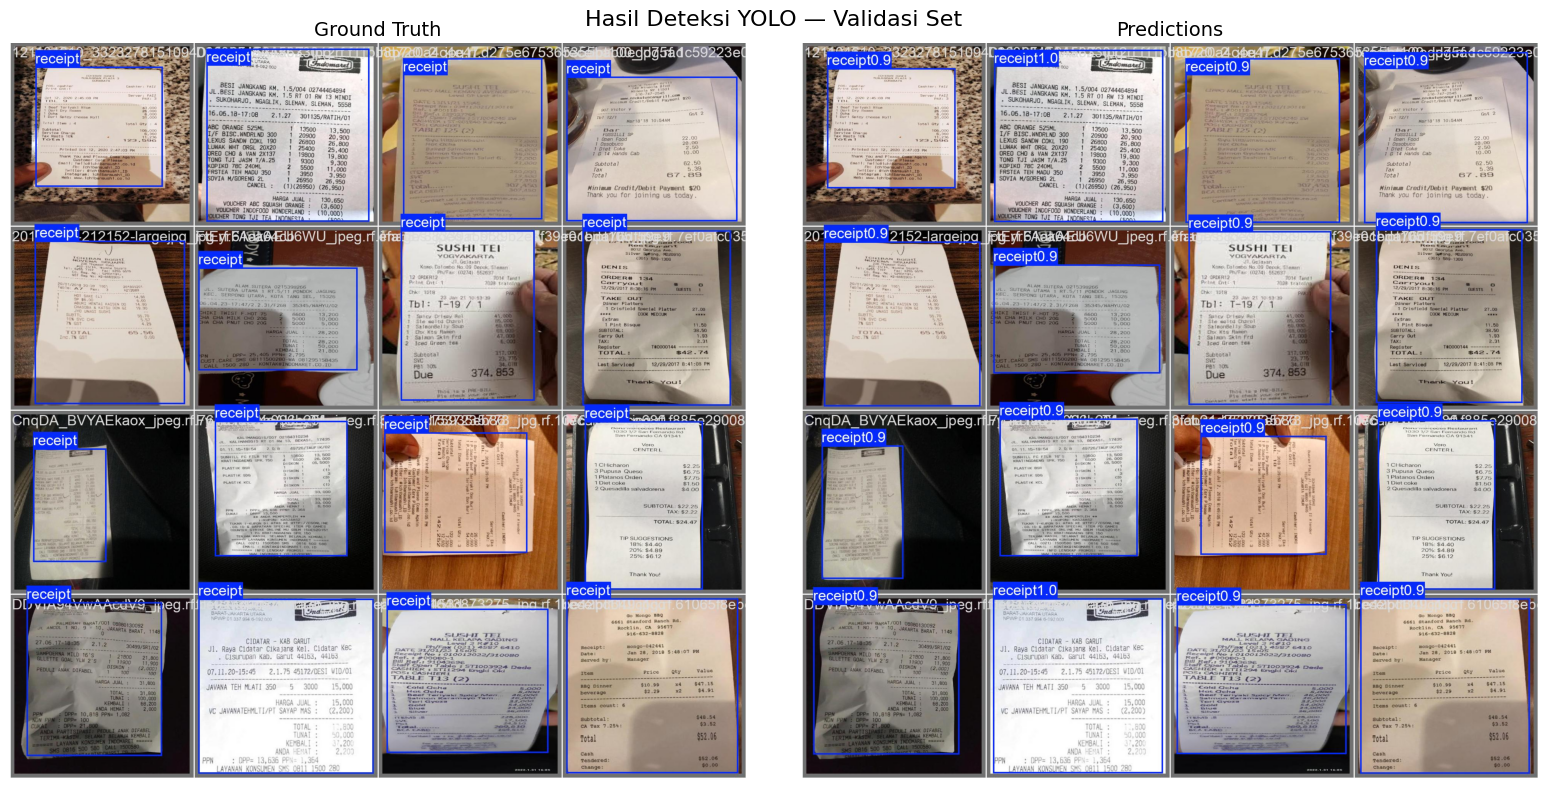

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(mpimg.imread("runs/detect/combined_receipt_detector/val_batch0_labels.jpg"))
axes[0].set_title("Ground Truth", fontsize=14)
axes[0].axis("off")

axes[1].imshow(mpimg.imread("runs/detect/combined_receipt_detector/val_batch0_pred.jpg"))
axes[1].set_title("Predictions", fontsize=14)
axes[1].axis("off")

plt.suptitle("Hasil Deteksi YOLO — Validasi Set", fontsize=16)
plt.tight_layout()
plt.show()

In [29]:
yolo_model = YOLO("runs/detect/combined_receipt_detector/weights/best.pt")
ocr_reader = easyocr.Reader(['id', 'en'], gpu=True)

In [30]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

client_llm = genai.Client(api_key=GEMINI_API_KEY)

In [23]:
def preprocess_receipt(image):
    """CLAHE untuk perbaiki kontras gambar struk"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(gray)
    return clahe_img

def detect_and_crop(image, conf=0.1, padding=30):
    """YOLO deteksi struk lalu crop + resize"""
    results = yolo_model(image, conf=conf)[0]
    if len(results.boxes) == 0:
        return image
    best_box = results.boxes[results.boxes.conf.argmax()]
    x1, y1, x2, y2 = map(int, best_box.xyxy[0].tolist())
    h, w = image.shape[:2]
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    cropped = image[y1:y2, x1:x2]
    ch, cw = cropped.shape[:2]
    if min(ch, cw) < 600:
        scale = 600 / min(ch, cw)
        cropped = cv2.resize(cropped, (int(cw * scale), int(ch * scale)),
                             interpolation=cv2.INTER_CUBIC)
    return cropped

def run_ocr(preprocessed_image):
    """EasyOCR ekstrak teks"""
    results = ocr_reader.readtext(preprocessed_image)
    lines = [text for (_, text, conf) in results if conf > 0.1]
    return "\n".join(lines)

In [20]:
def parse_with_llm(raw_text: str) -> dict:
    """Gemini LLM parse teks OCR → JSON"""
    prompt = f"""Kamu adalah asisten yang bertugas mengekstrak informasi dari teks struk belanja.

Teks OCR mentah dari struk:
\"\"\"
{raw_text}
\"\"\"

Kembalikan HANYA format JSON berikut, tanpa penjelasan apapun:
{{
  "nama_toko": null,
  "tanggal": null,
  "items": [
    {{
      "nama_item": "string",
      "qty": null,
      "harga": null,
      "subtotal": null
    }}
  ],
  "total_pengeluaran": null
}}

Aturan:
- qty berupa NUMBER (contoh: 2 bukan "2x")
- harga berupa NUMBER (contoh: 12000 bukan "Rp 12.000")
- subtotal berupa NUMBER hasil qty x harga
- total_pengeluaran berupa NUMBER
- Perbaiki typo OCR jika ada
- tanggal dikonversi ke format DD-MM-YYYY apapun format aslinya
- Jika tidak ditemukan, isi null
- Hanya kembalikan JSON, tidak ada teks lain"""

    try:
        response = client_llm.models.generate_content(
            model="gemini-3.5-flash",
            contents=prompt
        )
        raw_response = response.text.strip()
        raw_response = re.sub(r'^```json\s*', '', raw_response)
        raw_response = re.sub(r'\s*```$', '', raw_response)
        return json.loads(raw_response)
    except json.JSONDecodeError:
        return {"nama_toko": None, "tanggal": None, "items": [], "total_pengeluaran": None}
    except Exception as e:
        return {"error": str(e)}

def scan_receipt(image_path: str) -> dict:
    """Pipeline lengkap: path gambar → JSON"""
    image = cv2.imread(str(image_path))
    if image is None:
        return {"error": f"Gagal load gambar: {image_path}"}
    cropped = detect_and_crop(image)
    preprocessed = preprocess_receipt(cropped)
    ocr_text = run_ocr(preprocessed)
    if not ocr_text.strip():
        return {"error": "Tidak ada teks terdeteksi"}
    return parse_with_llm(ocr_text)

# Test Pipeline

Upload gambar struk:


Saving stuck-Beepos.jpg to stuck-Beepos (1).jpg

⏳ Memproses: stuck-Beepos (1).jpg

0: 640x384 1 receipt, 62.8ms
Speed: 2.4ms preprocess, 62.8ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)

📋 Hasil Ekstraksi:
{
  "nama_toko": "Cafe Bee",
  "tanggal": "24-05-2023",
  "items": [
    {
      "nama_item": "Bakso",
      "qty": 2,
      "harga": 12000,
      "subtotal": 24000
    },
    {
      "nama_item": "Cah Kangkung",
      "qty": 3,
      "harga": 7500,
      "subtotal": 22500
    },
    {
      "nama_item": "Cap Cay",
      "qty": 3,
      "harga": 17000,
      "subtotal": 51000
    },
    {
      "nama_item": "Cumi Goreng Tepung Gurih",
      "qty": 3,
      "harga": 25000,
      "subtotal": 75000
    }
  ],
  "total_pengeluaran": 191475
}

0: 640x384 1 receipt, 11.7ms
Speed: 3.3ms preprocess, 11.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)


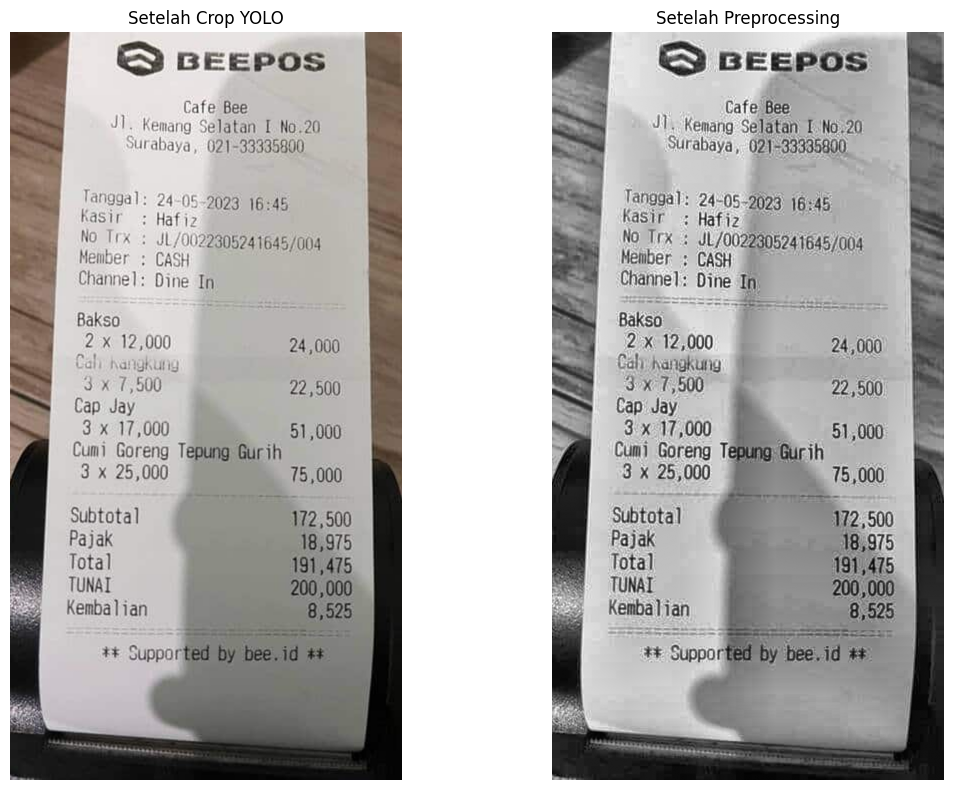

In [24]:
print("Upload gambar struk:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n⏳ Memproses: {filename}")
    result = scan_receipt(filename)
    print("\n📋 Hasil Ekstraksi:")
    print(json.dumps(result, indent=2, ensure_ascii=False))

    image = cv2.imread(filename)
    if image is not None:
        cropped = detect_and_crop(image)
        preprocessed = preprocess_receipt(cropped)
        fig, axes = plt.subplots(1, 2, figsize=(12, 8))
        axes[0].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Setelah Crop YOLO")
        axes[0].axis("off")
        axes[1].imshow(preprocessed, cmap="gray")
        axes[1].set_title("Setelah Preprocessing")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

In [25]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs("/content/drive/MyDrive/NotaLens/models", exist_ok=True)
shutil.copy(
    "runs/detect/combined_receipt_detector/weights/best.pt",
    "/content/drive/MyDrive/NotaLens/models/combined_best.pt"
)

Mounted at /content/drive


'/content/drive/MyDrive/NotaLens/models/combined_best.pt'